# HuggingFace FAQ Dataset — Exploratory Data Analysis (EDA)

This notebook explores the HuggingFace FAQ dataset:
- Category distribution
- Difficulty levels
- Answer/question length
- Common phrasing patterns (bigrams)
- Word cloud of frequent terms

### Cell 1 — Setup

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from wordcloud import WordCloud, STOPWORDS
from sklearn.feature_extraction.text import CountVectorizer

os.makedirs("../data/eda_outputs", exist_ok=True)

### Cell 2 — Load Data

In [2]:
df = pd.read_csv("../data/cleaned_faq_dataset.csv")

print(f"Loaded {len(df)} rows")
print(f"Columns: {list(df.columns)}")

Loaded 89 rows
Columns: ['category', 'difficulty_level', 'question', 'answer', 'requires_review', 'review_reason', 'metadata_tags']


### Cell 3 — Derived Columns

In [3]:
df['answer_word_count'] = df['answer'].apply(lambda x: len(str(x).split()))
df['question_word_count'] = df['question'].apply(lambda x: len(str(x).split()))

### Cell 4 — Category Distribution

In [4]:
cat_counts = df['category'].value_counts()

print("=== FINDING 1: Category Distribution ===")
print(cat_counts.to_string())

=== FINDING 1: Category Distribution ===
category
Orders & Shipping          34
Account & Profile          18
Returns & Refunds          17
Customer Support           12
General/Product Inquiry     5
Billing & Payments          3


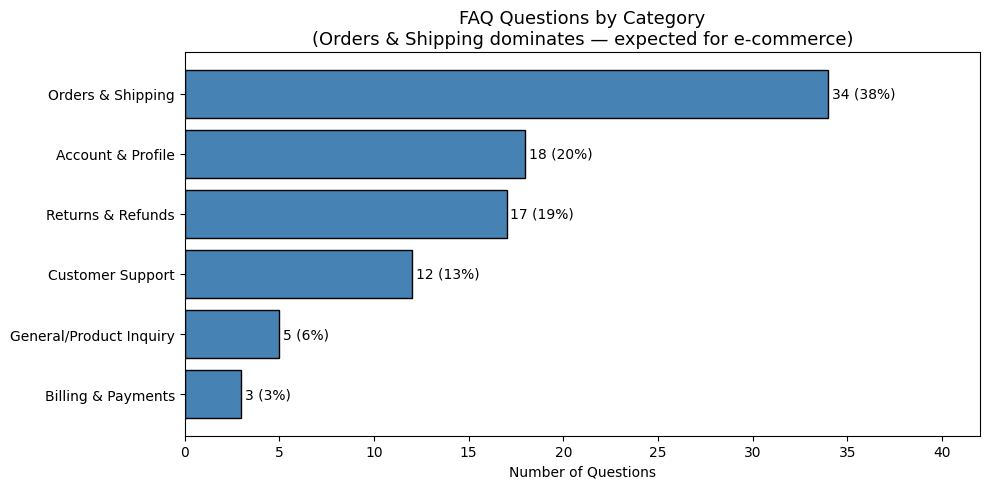

In [5]:
fig1, ax = plt.subplots(figsize=(10, 5))

bars = ax.barh(cat_counts.index[::-1], cat_counts.values[::-1],
               color='steelblue', edgecolor='black')

for bar, val in zip(bars, cat_counts.values[::-1]):
    ax.text(bar.get_width() + 0.2,
            bar.get_y() + bar.get_height() / 2,
            f'{val} ({val / len(df) * 100:.0f}%)',
            va='center', fontsize=10)

ax.set_title('FAQ Questions by Category\n(Orders & Shipping dominates — expected for e-commerce)', fontsize=13)
ax.set_xlabel('Number of Questions')
ax.set_xlim(0, cat_counts.max() + 8)

plt.tight_layout()

plt.savefig('../data/eda_outputs/faq_1_category_distribution.png',
            dpi=150, bbox_inches='tight')

plt.show()

### Cell 5 — Difficulty & Answer Length

In [6]:
diff_counts = df['difficulty_level'].value_counts()

print("\n=== FINDING 2: Difficulty Distribution ===")
print(diff_counts.to_string())
print(">>> NOTE: Word-count threshold produces mostly 'Intermediate' — not a useful signal here")


=== FINDING 2: Difficulty Distribution ===
difficulty_level
Intermediate    89
>>> NOTE: Word-count threshold produces mostly 'Intermediate' — not a useful signal here


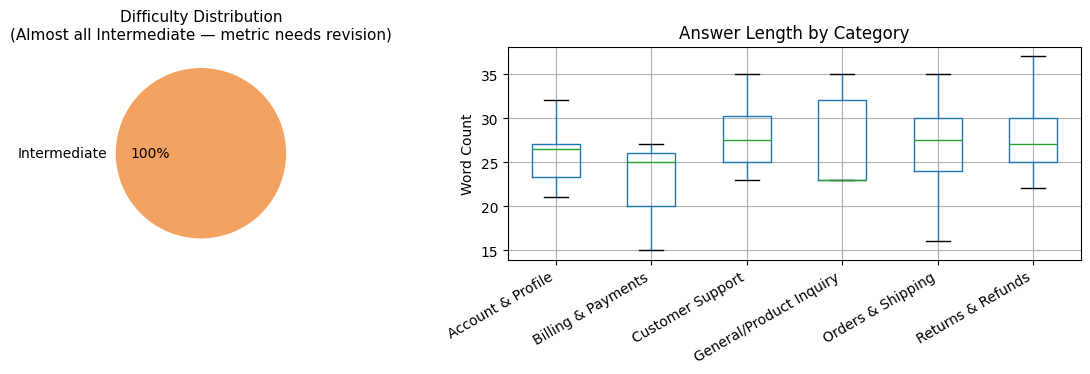

In [7]:
fig2, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].pie(diff_counts.values,
            labels=diff_counts.index,
            autopct='%1.0f%%',
            colors=['#f4a261', '#2a9d8f', '#e76f51'])

axes[0].set_title('Difficulty Distribution\n(Almost all Intermediate — metric needs revision)', fontsize=11)

df.boxplot(column='answer_word_count', by='category', ax=axes[1])

axes[1].set_title('Answer Length by Category')
axes[1].set_xlabel('')
axes[1].set_ylabel('Word Count')

plt.suptitle('')
plt.xticks(rotation=30, ha='right')
plt.tight_layout()

plt.savefig('../data/eda_outputs/faq_2_difficulty_and_length.png',
            dpi=150, bbox_inches='tight')

plt.show()

### Cell 6 — Top Bigrams

In [8]:
print("\n=== FINDING 3: Top Bigrams in Questions ===")

vec = CountVectorizer(ngram_range=(2, 2),
                      stop_words='english',
                      max_features=12)

bigram_matrix = vec.fit_transform(df['question'])

bigram_counts = pd.Series(
    bigram_matrix.toarray().sum(axis=0),
    index=vec.get_feature_names_out()
).sort_values(ascending=False)

print(bigram_counts.to_string())


=== FINDING 3: Top Bigrams in Questions ===
product listed       20
order product        19
return product       17
request product      13
product purchased     8
pre order             8
available pre         6
coming soon           5
listed coming         5
listed stock          4
product currently     4
soon available        4


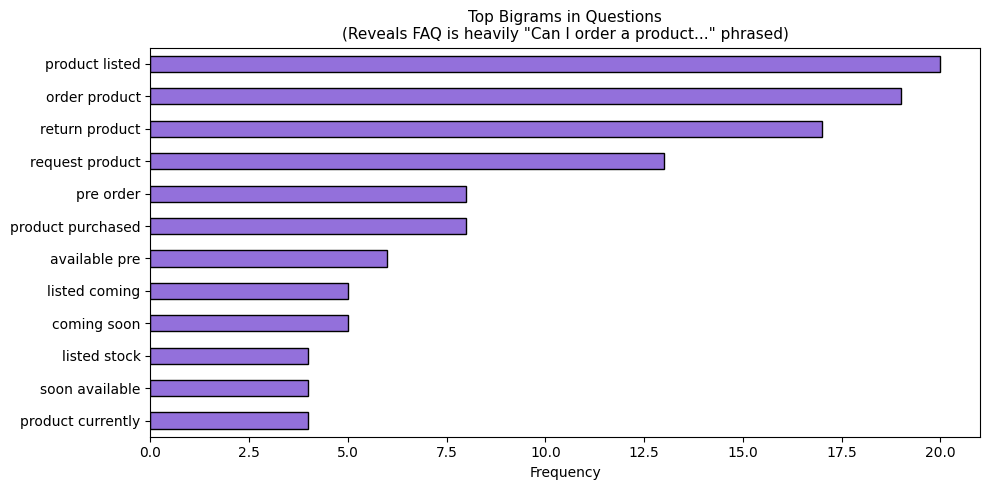

In [9]:
fig3, ax = plt.subplots(figsize=(10, 5))

bigram_counts.sort_values().plot(
    kind='barh',
    ax=ax,
    color='mediumpurple',
    edgecolor='black'
)

ax.set_title('Top Bigrams in Questions\n(Reveals FAQ is heavily "Can I order a product..." phrased)', fontsize=11)
ax.set_xlabel('Frequency')

plt.tight_layout()

plt.savefig('../data/eda_outputs/faq_3_bigrams.png',
            dpi=150, bbox_inches='tight')

plt.show()

### Cell 7 — Word Cloud

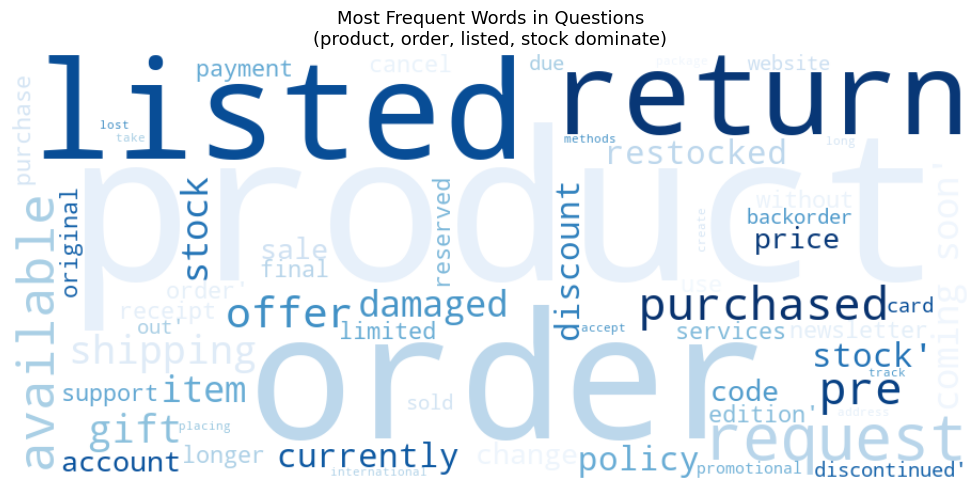

In [10]:
custom_stopwords = STOPWORDS.union({
    'can', 'I', 'my', 'your', 'you', 'it', 'is', 'we', 'our',
    'please', 'will', 'also', 'may', 'one', 'us'
})

text = ' '.join(df['question'].tolist())

wc = WordCloud(
    width=900,
    height=400,
    background_color='white',
    stopwords=custom_stopwords,
    colormap='Blues',
    max_words=60
).generate(text)

fig4, ax = plt.subplots(figsize=(12, 5))

ax.imshow(wc, interpolation='bilinear')
ax.axis('off')

ax.set_title('Most Frequent Words in Questions\n(product, order, listed, stock dominate)', fontsize=13)

plt.tight_layout()

plt.savefig('../data/eda_outputs/faq_4_wordcloud.png',
            dpi=150, bbox_inches='tight')

plt.show()

### Cell 8 — Length Distributions

In [11]:
print("\n=== FINDING 5: Answer Word Count Stats ===")
print(df['answer_word_count'].describe().round(1).to_string())


=== FINDING 5: Answer Word Count Stats ===
count    89.0
mean     27.0
std       4.4
min      15.0
25%      24.0
50%      27.0
75%      30.0
max      37.0


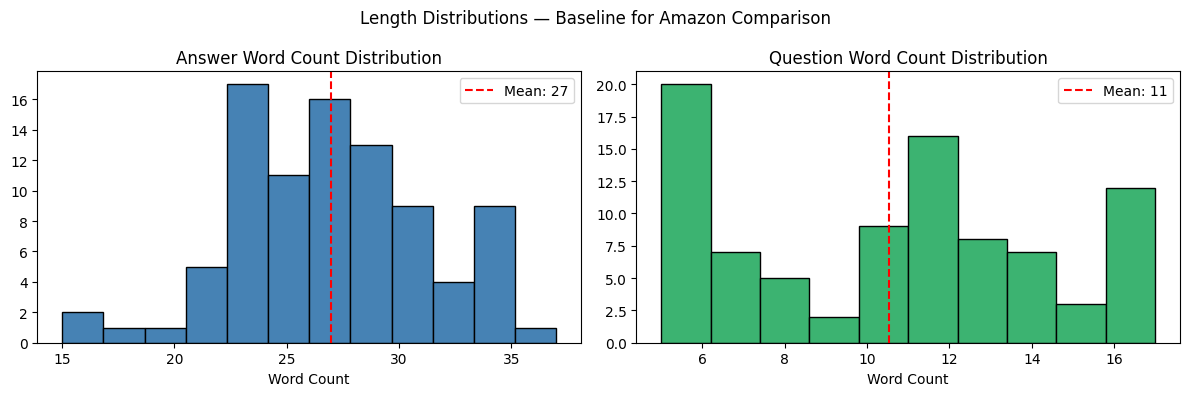

In [12]:
fig5, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['answer_word_count'],
             bins=12,
             color='steelblue',
             edgecolor='black')

axes[0].axvline(df['answer_word_count'].mean(),
                color='red',
                linestyle='--',
                label=f"Mean: {df['answer_word_count'].mean():.0f}")

axes[0].set_title('Answer Word Count Distribution')
axes[0].set_xlabel('Word Count')
axes[0].legend()

axes[1].hist(df['question_word_count'],
             bins=10,
             color='mediumseagreen',
             edgecolor='black')

axes[1].axvline(df['question_word_count'].mean(),
                color='red',
                linestyle='--',
                label=f"Mean: {df['question_word_count'].mean():.0f}")

axes[1].set_title('Question Word Count Distribution')
axes[1].set_xlabel('Word Count')
axes[1].legend()

plt.suptitle('Length Distributions — Baseline for Amazon Comparison', fontsize=12)
plt.tight_layout()

plt.savefig('../data/eda_outputs/faq_5_length_distributions.png',
            dpi=150, bbox_inches='tight')

plt.show()

### Cell 9 — Summary

In [14]:
print("\n" + "=" * 60)
print("SUMMARY OF KEY FINDINGS")
print("=" * 60)

print(f"  Total records       : {len(df)}")
print(f"  Unique categories   : {df['category'].nunique()}")
print(
    f"  Dominant category   : {cat_counts.index[0]} ({cat_counts.iloc[0]} rows, {cat_counts.iloc[0] / len(df) * 100:.0f}%)")
print(f"  Difficulty spread   : {diff_counts.to_dict()}")
print(f"  Avg answer length   : {df['answer_word_count'].mean():.0f} words")
print(f"  Avg question length : {df['question_word_count'].mean():.0f} words")
print(f"  Requires review     : {df['requires_review'].sum()} rows")


SUMMARY OF KEY FINDINGS
  Total records       : 89
  Unique categories   : 6
  Dominant category   : Orders & Shipping (34 rows, 38%)
  Difficulty spread   : {'Intermediate': 89}
  Avg answer length   : 27 words
  Avg question length : 11 words
  Requires review     : 0 rows
